   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


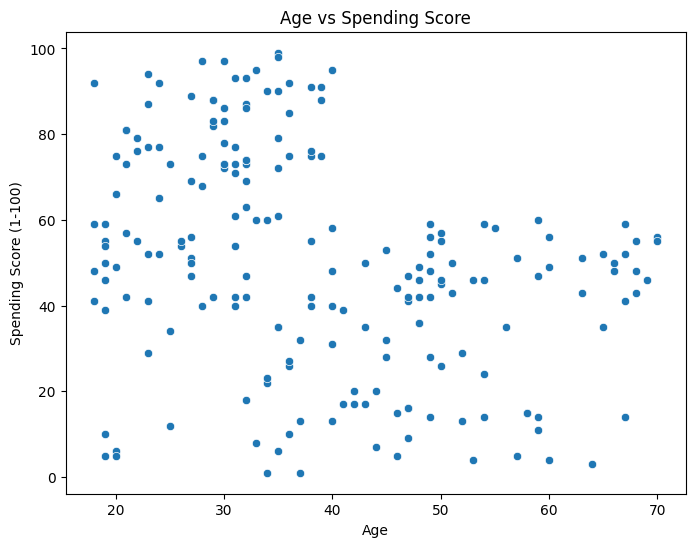

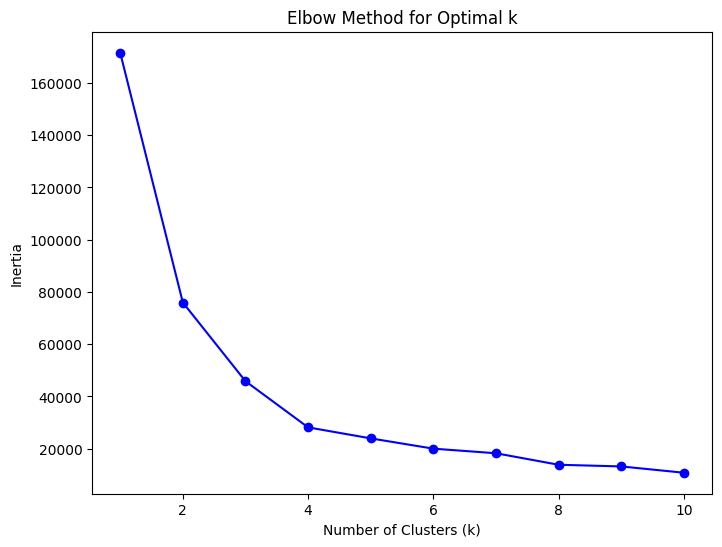

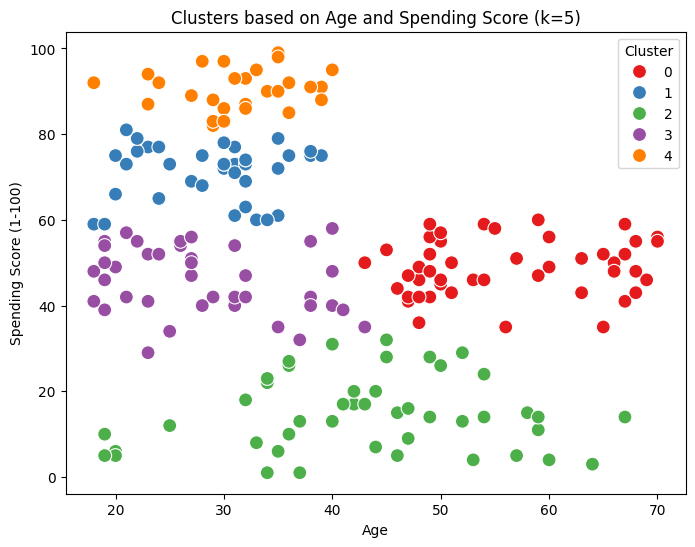

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Step 1: Load customer data
customers = pd.read_csv('customers.csv')

# Display the first few rows to understand the data
print(customers.head())

# Step 2: Check for missing values in each column
null_values = customers.isnull().sum()
print("Missing values per column:")
print(null_values)

# Step 3: Create a scatter plot with Age as X and Spending Score as Y
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=customers)
plt.title('Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show()

# Step 4: Find the optimal number of clusters using the Elbow Method
X = customers[['Age', 'Spending Score (1-100)']]

# List to store the sum of squared distances (inertia)
inertia_values = []

# Run KMeans for k values from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8,6))
plt.plot(range(1, 11), inertia_values, marker='o', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

# Step 5: Draw a scatter plot displaying data points colored on the basis of clusters
optimal_k = 5  # Assuming 5 is the best number from the Elbow method
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
customers['Cluster'] = kmeans.fit_predict(X)

# Scatter plot with clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='Cluster', palette='Set1', data=customers, s=100)
plt.title(f'Clusters based on Age and Spending Score (k={optimal_k})')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()
